## Definizioni

In [1]:
import numpy as np
from qutip import *
import matplotlib.pyplot as plt
from matplotlib.pyplot import plot
from numpy import pi, sqrt, linspace, exp, sin, cos, abs, angle, log, max, real
from scipy.special import erf, erfc
from scipy.integrate import cumulative_trapezoid
from math import atan2
from multiprocessing import Pool, cpu_count
from itertools import starmap, product
# import multiprocess as mp
# from pathos.multiprocessing import ProcessingPool as pPool
# from concurrent.futures import ProcessPoolExecutor as cPool

nlev = 2

ain = tensor(destroy(nlev), identity(nlev), identity(2), identity(2))
ainc = ain.dag()
a = tensor(identity(nlev), destroy(nlev), identity(2), identity(2))
ac = a.dag()
sz1 = tensor(identity(nlev), identity(nlev), sigmaz(), identity(2))
sz2 = tensor(identity(nlev), identity(nlev), identity(2), sigmaz())
sx1 = tensor(identity(nlev), identity(nlev), sigmax(), identity(2))
sx2 = tensor(identity(nlev), identity(nlev), identity(2), sigmax())
Ry1 = tensor(identity(nlev), identity(nlev), Qobj([[1,-1],[1,1]])/sqrt(2), identity(2)) # Matrice rotazione y di pi/2
Ry2 = tensor(identity(nlev), identity(nlev), identity(2), Qobj([[1,-1],[1,1]])/sqrt(2)) # Matrice rotazione y di pi/2
Ry = tensor(identity(nlev), identity(nlev), Qobj([[1,-1],[1,1]])/sqrt(2), Qobj([[1,-1],[1,1]])/sqrt(2)) # Matrice rotazione y di pi/2

Hd = tensor(identity(nlev),identity(nlev), Qobj([[1,1],[1,-1]])/sqrt(2),identity(2)) # Hadamard sul qubit 1
CNOT = tensor(identity(nlev),identity(nlev), Qobj([[1,0,0,0],[0,1,0,0],[0,0,0,1],[0,0,1,0]], dims=[[2,2],[2,2]])) # CNOT qubit 1 su qubit 2

def u(t): # pulse shape
    return exp(-t**2)

def gu(t):  # coefficient function
    return sqrt(2/sqrt(pi)*exp(-t**2)/erfc(t))

def bout(t, args):
    gm = args['gm']
    return sqrt(gm)*a + gu(t)*ain

def ry(rho, verso = 0):
    return Ry*rho*Ry.dag() if verso==0 else Ry.dag()*rho*Ry

# Funzione di simulazione
def sim(args,rho0,t1,t2):
    gm = args['gm']
    chi1 = args['chi1']
    chi2 = args['chi2']
    chi12 = args['chi12']
    Hc = 1j/2*sqrt(gm)*(ainc*a-ain*ac)
    Hq = -chi1/2*ac*a*sz1 - chi2/2*ac*a*sz2 - chi12/2*sx1*sx2
    H = [Hq,[Hc, gu]]
    L = [lambda t, args: bout(t, args)]
    t_ = linspace(t1, t2, 200)
    rho_ = mesolve(H, rho0, t_, L, args=args).states # SIMULAZIONE
    return t_,rho_

# Contour plot formattato
def pcont(R1,R2,P,xlab = r'Coupling $\chi_1/\gamma$',ylab = r'Coupling $\chi_1/\gamma$',title = 'P(not 00)',livelli= [0,.05,.1,.2,.3,.4,.5,.6,.7,.8,.9,.95,.99,1]):
    cf = plt.contourf(R1,R2,P, levels = [0,.1,.2,.3,.4,.5,.6,.7,.8,.9,.95,.99,1], cmap='rainbow')
    plt.colorbar(cf, fraction=0.04)
    cs = plt.contour(R1,R2,P, levels=livelli, colors = 'k', linewidths=0.2)
    plt.clabel(cs, inline=True, fontsize=8)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.xlabel(xlab)
    plt.ylabel(ylab)
    plt.title(title)
    return cf

# Plot mappa 2qubit
def plotsim(R1,R2,P):
    plt.figure(figsize=(10, 10))
    plt.subplot(2, 2, 1)
    pcont(R1,R2,1-P[:,:,0], title='1-P00')
    plt.subplot(2, 2, 2)
    pcont(R1,R2,P[:,:,3], title='P11')
    plt.subplot(2, 2, 3)
    pcont(R1,R2,P[:,:,1], title='P01')
    plt.subplot(2, 2, 4)
    pcont(R1,R2,P[:,:,2], title='P10')
    plt.tight_layout()

# Funzione di simulazione con misure intermedie: evoluzione e probabilità sequenza di risultati su cui vengono proiettate le misure
def simseq(gm = 10, chi = 10, stato = [0,0,0,0], ti = -5, tf = 5):
    args = {'gm':gm,'chi':chi}
    nseq = len(stato)
    tseq_ = np.linspace(ti, tf, nseq+1)
    psi0 = tensor(basis(nlev,1), basis(nlev,0), basis(2,0))
    rho0 = psi0*psi0.dag()
    t_,rho_ = [],[]
    for k in range(nseq):
        t1 = tseq_[k]
        t2 = tseq_[k+1]
        rho0 = ry(rho0,0) # Rotazione di pi/2 dello stato iniziale
        tp_,rhop_ = sim(args,rho0,t1,t2) # Evoluzione
        t_ = np.concatenate((t_,tp_))
        rho_ = np.concatenate((rho_,rhop_))
        rhof = ry(rho_[-1], 1)  # Rotazione di -pi/2 dell'ultimo stato
        rho0 = proj(rhof, stato[k]) # Proiezione dello stato sul risultato 'stato'
        pf = rho0.tr()
    return t_, rho_, pf, tseq_ # restituiti: tempi, matrice densità con norma decrescente, probabilità della sequenza totale, tempi inizio e fine tratti protocollo misura

## Singolo qubit

### Evoluzione nel tempo

Text(0.5, 1.0, '$\\gamma$=10$\\Delta t$, $\\chi_1$=10$\\Delta t$')

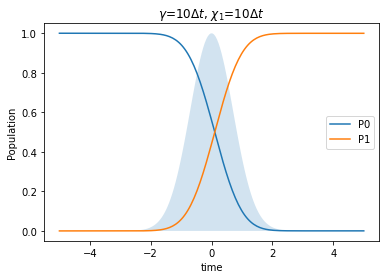

In [2]:
# Simulazione - sovrapposizione stati
args = {'gm':10,'chi1':10, 'chi2':0, 'chi12':0}

psi0 = tensor(basis(nlev,1), basis(nlev,0), basis(2,0), basis(2,0))
rho0 = ry( psi0*psi0.dag(), 0)
t_,rho_ = sim(args, rho0, -5, 5)
rho_ = [ ry(rho, 1) for rho in rho_]

p_ = np.array([real(np.diag(ptrace(rho,[2,3]).full())) for rho in rho_])
plt.plot(t_, p_[:,0], label='P0')
plt.plot(t_, p_[:,2], label='P1')
plt.legend()
plt.fill(t_, u(t_), alpha=.2)
plt.xlabel('time')
plt.ylabel(r'Population')
plt.title(fr'$\gamma$={args["gm"]}$\Delta t$, $\chi_1$={args["chi1"]}$\Delta t$')

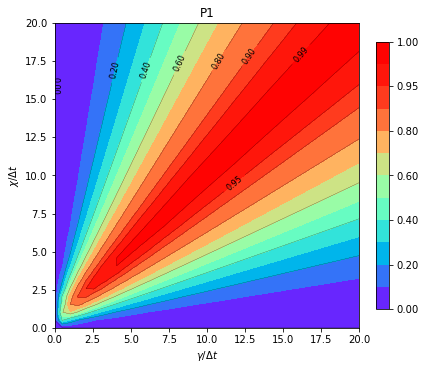

In [172]:
ngrid = 40
gm_ = np.linspace(0,20,ngrid)
chi_ = np.linspace(0,20,ngrid)

psi0 = tensor(basis(nlev,1), basis(nlev,0), basis(2,0), basis(2,0))
rho0 = ry( psi0*psi0.dag(), 0) 

def fsim(arg):
    gm,chi = arg[0], arg[1]
    args = {'gm':gm,'chi1':chi, 'chi2':0, 'chi12':0}
    t_,rho_ = sim(args, rho0, -5, 5)
    rhof = ry(rho_[-1], 1)
    return real(np.diag(ptrace(rhof,[2,3]).full()))

parlist = [(gm,chi) for chi in chi_ for gm in gm_]
with Pool(processes=15) as pool:
    P = np.array(list(pool.map(fsim, parlist))).reshape(ngrid,ngrid,4)
R1,R2 = np.meshgrid(gm_,chi_)

plt.figure(figsize=(6,6))
pcont(R1, R2, P[:,:,2], xlab=r'$\gamma/\Delta t$', ylab=r'$\chi/\Delta t$', title='P1', livelli=[0,.2,.4,.6,.8,.9,.95,.99,1])

## Due qubit disaccoppiati

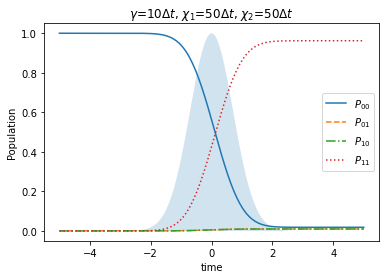

In [45]:
# Simulazione - sovrapposizione stati
args = {'gm':10,'chi1':50, 'chi2':50, 'chi12':0}

psi0 = tensor(basis(nlev,1), basis(nlev,0), basis(2,0), basis(2,0))
rho0 = ry( psi0*psi0.dag(), 0)
t_,rho_ = sim(args, rho0, -5, 5)
rho_ = [ ry(rho, 1) for rho in rho_]

p_ = np.array([real(np.diag(ptrace(rho,[2,3]).full())) for rho in rho_])
lab = [r'$P_{00}$', r'$P_{01}$', r'$P_{10}$', r'$P_{11}$']
lin = ['-','--','-.',':']
for k in range(4):
    plt.plot(t_, p_[:,k], label=lab[k], linestyle=lin[k]   )
plt.legend()
plt.fill(t_, u(t_), alpha=.2)
plt.xlabel('time')
plt.ylabel(r'Population')
plt.title(fr'$\gamma$={args["gm"]}$\Delta t$, $\chi_1$={args["chi1"]}$\Delta t$, $\chi_2$={args["chi2"]}$\Delta t$');

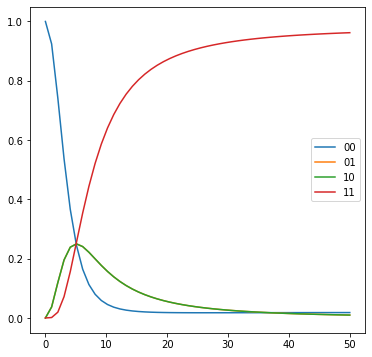

In [113]:
ngrid = 50
gm = 10
chi_ = np.linspace(0,50,ngrid)

psi0 = tensor(basis(nlev,1), basis(nlev,0), basis(2,0), basis(2,0))
rho0 = ry( psi0*psi0.dag(), 0) 

def fsim(arg):
    gm,chi = arg[0],arg[1]
    args = {'gm':gm,'chi1':chi, 'chi2':chi, 'chi12':0}
    t_,rho_ = sim(args, rho0, -5, 5)
    rhof = ry(rho_[-1], 1)
    return real(np.diag(ptrace(rhof,[2,3]).full()))

parlist = [(gm,chi) for chi in chi_]
with Pool(processes=15) as pool:
    P = np.array(list(pool.map(fsim, parlist))).reshape(ngrid,4)

plt.figure(figsize=(6,6))
plt.plot(chi_,P, label = ['00','01','10','11'])
plt.legend()

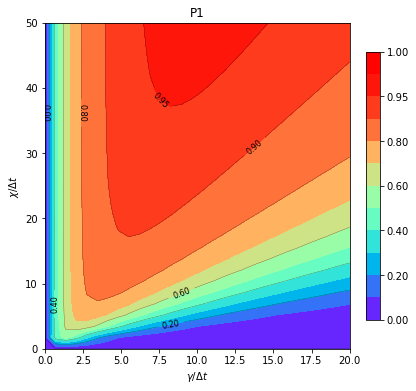

In [184]:
ngrid1 = 30
ngrid2 = 30
gm_ = np.linspace(0,20,ngrid1)
chi_ = np.linspace(0,50,ngrid2)

psi0 = tensor(basis(nlev,1), basis(nlev,0), basis(2,0), basis(2,0))
rho0 = ry( psi0*psi0.dag(), 0) 

def fsim(arg):
    gm,chi = arg[0],arg[1]
    args = {'gm':gm,'chi1':chi, 'chi2':chi, 'chi12':0}
    t_,rho_ = sim(args, rho0, -5, 5)
    rhof = ry(rho_[-1], 1)
    return real(np.diag(ptrace(rhof,[2,3]).full()))

parlist = [(gm,chi) for chi in chi_ for gm in gm_]
with Pool(processes=15) as pool:
    P = np.array(list(pool.map(fsim, parlist))).reshape(ngrid2,ngrid1,4)
R1,R2 = np.meshgrid(gm_,chi_)

plt.figure(figsize=(6,6))
pcont(R1, R2, P[:,:,3], xlab=r'$\gamma/\Delta t$', ylab=r'$\chi/\Delta t$', title='P1', livelli=[0,.2,.4,.6,.8,.9,.95,.99,1])
plt.gca().set_aspect('auto', adjustable='box')

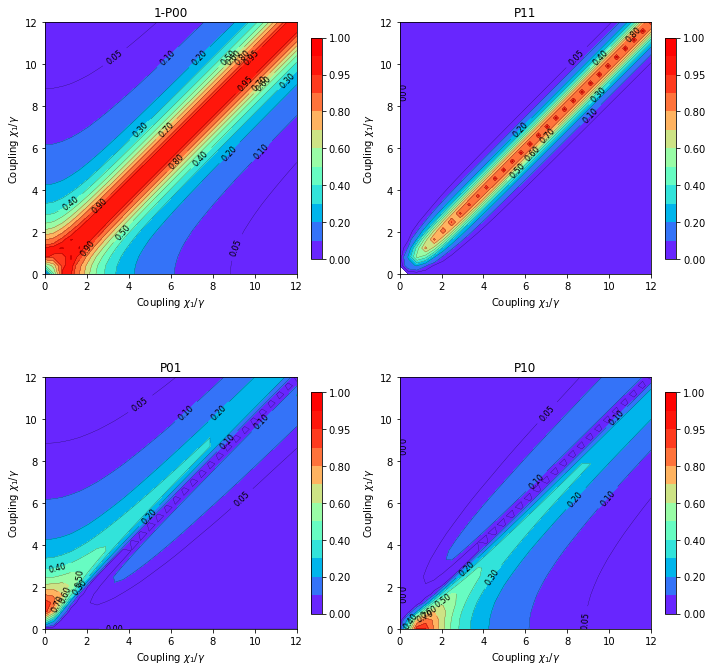

In [183]:
ngrid = 30
gm = 10
rchi1_ = np.linspace(0,12,ngrid)
rchi2_ = np.linspace(0,12,ngrid)

psi0 = tensor(basis(nlev,1), basis(nlev,0), basis(2,0), basis(2,0))
rho0 = ry( psi0*psi0.dag(), 0) 

def fsim(arg):
    gm,rchi1,rchi2 = arg[0], arg[1], arg[2]
    args = {'gm':gm,'chi1':gm*rchi1, 'chi2':gm*rchi2, 'chi12':0}
    t_,rho_ = sim(args, rho0, -5, 5)
    rhof = ry(rho_[-1], 1)
    return real(np.diag(ptrace(rhof,[2,3]).full()))

parlist = [(gm, r1, r2) for r2 in rchi2_ for r1 in rchi1_]
with Pool(processes=15) as pool:
    P = np.array(list(pool.map(fsim, parlist))).reshape(ngrid,ngrid,4)
R1,R2 = np.meshgrid(rchi1_,rchi2_)

plotsim(R1,R2,P)

## Due qubit accoppiati

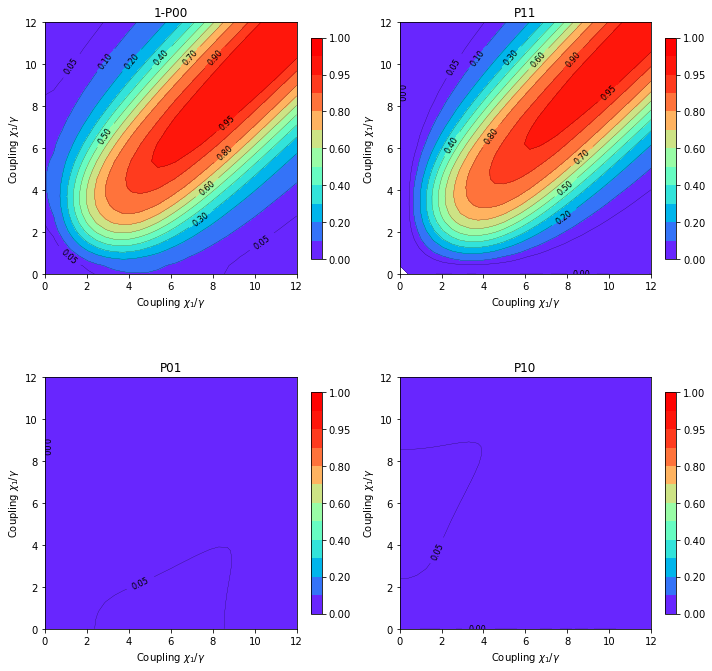

In [2]:
ngrid = 30
gm = 10
chi12 = 10*gm
rchi1_ = np.linspace(0,12,ngrid)
rchi2_ = np.linspace(0,12,ngrid)

psi0 = tensor(basis(nlev,1), basis(nlev,0), basis(2,0), basis(2,0))
rho0 = ry( psi0*psi0.dag(), 0) 

def fsim(arg):
    gm,rchi1,rchi2,chi12 = arg[0], arg[1], arg[2], arg[3]
    args = {'gm':gm,'chi1':gm*rchi1, 'chi2':gm*rchi2, 'chi12':chi12}
    t_,rho_ = sim(args, rho0, -5, 5)
    rhof = ry(rho_[-1], 1)
    return real(np.diag(ptrace(rhof,[2,3]).full()))

parlist = [(gm, r1, r2, chi12) for r1, r2 in product(rchi1_, rchi2_)]
with Pool(processes=15) as pool:
    P = np.array(list(pool.map(fsim, parlist))).reshape(ngrid,ngrid,4)
R1,R2 = np.meshgrid(rchi1_,rchi2_)

plotsim(R1,R2,P)

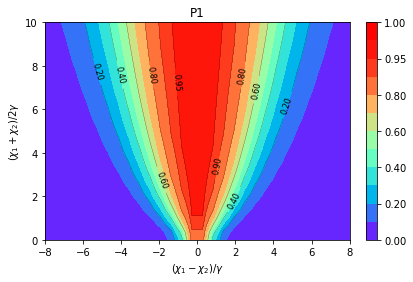

In [15]:
ngrid1 = 30
ngrid2 = 30
gm = 10
rchi12_ = np.linspace(0,10,ngrid1)
rchim = 10
drchi_ = np.linspace(-8,8,ngrid2)

psi0 = tensor(basis(nlev,1), basis(nlev,0), basis(2,0), basis(2,0))
rho0 = ry( psi0*psi0.dag(), 0) 

def fsim(arg):
    gm,rchim,drchi,rchi12 = arg[0], arg[1], arg[2], arg[3]
    args = {'gm':gm,'chi1':gm*(rchim+drchi/2), 'chi2':gm*(rchim-drchi/2), 'chi12':gm*rchi12}
    t_,rho_ = sim(args, rho0, -5, 5)
    rhof = ry(rho_[-1], 1)
    return real(np.diag(ptrace(rhof,[2,3]).full()))

parlist = [(gm, rchim, drchi, rchi12) for rchi12 in rchi12_ for drchi in drchi_]
with Pool(processes=15) as pool:
    P = np.array(list(pool.map(fsim, parlist))).reshape(ngrid1,ngrid2,4)
R1,R2 = np.meshgrid(drchi_,rchi12_)

pcont(R1, R2, P[:,:,3], xlab=r'$(\chi_1-\chi_2)/\gamma$', ylab=r'$(\chi_1+\chi_2)/2\gamma$', title='P1', livelli=[0,.2,.4,.6,.8,.9,.95,.99,1])
plt.gca().set_aspect('auto', adjustable='box')

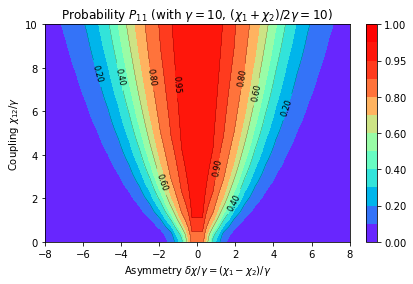

In [26]:
pcont(R1, R2, P[:,:,3], xlab=r'Asymmetry $\delta \chi/\gamma = (\chi_1-\chi_2)/\gamma$', ylab=r'Coupling $\chi_{12}/\gamma$', title=r'Probability $P_{11}$ (with $\gamma=10$, $(\chi_1+\chi_2)/2\gamma=10$)', livelli=[0,.2,.4,.6,.8,.9,.95,.99,1])
plt.gca().set_aspect('auto', adjustable='box')